Hugo Manzano 36231

Solo importamos librerias

In [21]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Conversion de pil a tensores

In [23]:
#Encontre que para convertir de pil a tensores es con el metodo ToTensor y los pone con valores de 0 y 1
transform = transforms.ToTensor()

#Aqui solamente distinguimos las particiones y ya con el transform se aplica la conversion cada que se accede a una imagen
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#Con el dataloader hacemos mini batches de 64 imagenes cada que se itera y ademas se mezcla todo en train en cada epoca
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

#Se imprime el output para mostrar todo acerca de clases y la longituf
CLASSES = train_dataset.classes
print('Clases:', CLASSES)
print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000 | Test: 10000


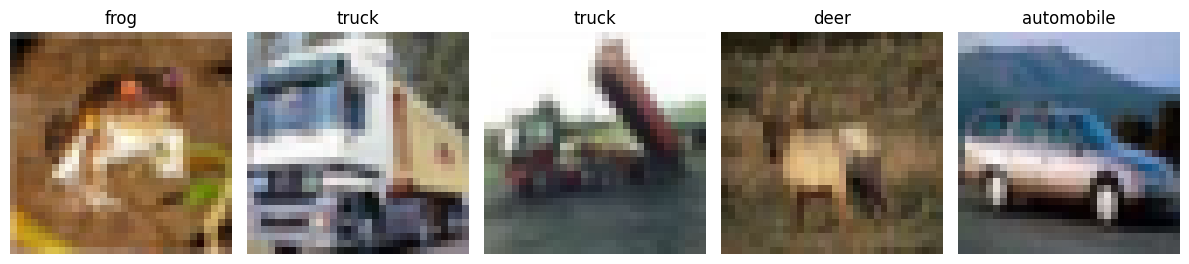

In [24]:
#Aqui solo mostré 5 imagenes y se ordenan los puntos CHW que usa pytorch para que quede como HWC y matplotlib pueda leerlos realmente no cambia nada en el proceso jajajaj
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.permute(1, 2, 0))  # aqui cambiamos CHW A HWC
    ax.set_title(CLASSES[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [25]:
#Solo queremos tener el accuracy de cada batch por que esto nos ayuda a tener mejor visibilidad en cuanto a errores de falsos positivos
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [26]:
#Funcionn de entrenamiento
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc':  [],
        'test_loss':  [],
        'test_acc':   [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc  = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc  += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        #Evaluamos el modelo
        _model.eval()
        test_loss = 0.0
        test_acc  = 0.0
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test, y_test = X_test.to(device), y_test.to(device)
                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc  += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        #Aqui basicamente buscamos calcular la perdida sin modificaciones extras
        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

In [27]:
#Aqui es ñla evaluación final después de terminar el entrenamiento. Igual que la parte de evaluación dentro de train pero regresa los valores para poder compararlos entre modelos.
def test(_model, _test_loader, _criterion):
    _model.eval()
    test_loss = 0.0
    test_acc  = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _criterion(output, y).item() * x.size(0)
            test_acc  += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

Entrenamiento de los modelos

In [28]:
epochs = 20
loss_function = nn.CrossEntropyLoss()

Modelo de 1 capa con 2 bloques conv

In [29]:
model_small = nn.Sequential(
    nn.Conv2d(3, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_small = model_small.to(device)

In [30]:
optimizer = Adam(model_small.parameters())

res_small = train(model_small, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:33<00:00, 10.69s/epoch, test_acc=0.6835, test_loss=2.1976, train_acc=0.9822, train_loss=0.0527]


Modelo con 3 bloques conv

In [31]:
model_medium = nn.Sequential(
    nn.Conv2d(3, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_medium = model_medium.to(device)

In [32]:
optimizer = Adam(model_medium.parameters())

res_medium = train(model_medium, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:42<00:00, 11.12s/epoch, test_acc=0.7286, test_loss=1.6741, train_acc=0.9701, train_loss=0.0862]


Aqui tenemos el modelo 3 pero tiene la misma profundidad por asi decirlo
solo que tiene el batchnorm2d despues de cada convolucion para mejorar el entrenamiento bueno la estabilizacion y pues solamente agregue el metodo Dropout para reducir el overfitting

In [33]:
model_bn = nn.Sequential(
    nn.Conv2d(3, 32, 3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_bn = model_bn.to(device)

In [34]:
optimizer = Adam(model_bn.parameters())

res_bn = train(model_bn, train_loader, test_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [03:50<00:00, 11.50s/epoch, test_acc=0.7674, test_loss=1.0262, train_acc=0.9416, train_loss=0.1641]


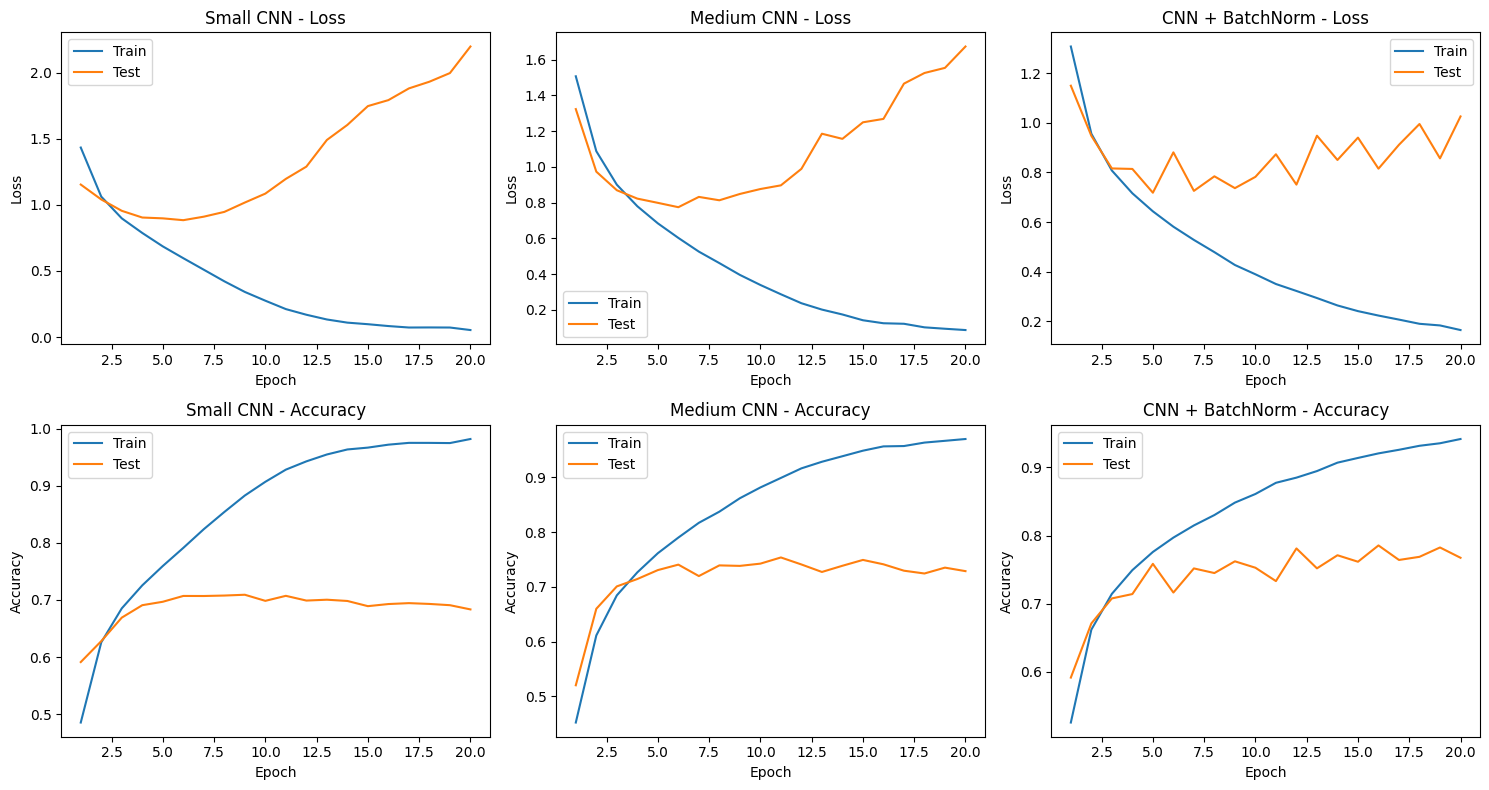

In [35]:

results = {
    'Small CNN':       res_small,
    'Medium CNN':      res_medium,
    'CNN + BatchNorm': res_bn,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ep = range(1, epochs + 1)


#Aqui use IA para apoyarme a graficar ya que me interesa que quede presentable pero realmente todo está entendido

for col, (name, res) in enumerate(results.items()):
    axes[0, col].plot(ep, res['train_loss'], label='Train')
    axes[0, col].plot(ep, res['test_loss'],  label='Test')
    axes[0, col].set_title(f"{name} - Loss")
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()

    axes[1, col].plot(ep, res['train_acc'], label='Train')
    axes[1, col].plot(ep, res['test_acc'],  label='Test')
    axes[1, col].set_title(f"{name} - Accuracy")
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()

plt.tight_layout()
plt.show()

In [36]:
#Evaluamos los modelos y los tomamos como el bloque anterior
models = {
    'Small CNN':       model_small,
    'Medium CNN':      model_medium,
    'CNN + BatchNorm': model_bn,
}

best_name  = None
best_acc   = 0.0
best_model = None

#Llamamos a model y nos quedamos con el que tenga mejor accuracy
for name, model in models.items():
    loss, acc = test(model, test_loader, loss_function)
    print(f"{name}: loss={loss:.4f} | accuracy={acc:.4f} ({acc*100:.2f}%)")
    if acc > best_acc:
        best_acc   = acc
        best_name  = name
        best_model = model

print(f"\nBest model: {best_name} with {best_acc*100:.2f}% accuracy")

Small CNN: loss=2.1976 | accuracy=0.6835 (68.35%)
Medium CNN: loss=1.6741 | accuracy=0.7286 (72.86%)
CNN + BatchNorm: loss=1.0262 | accuracy=0.7674 (76.74%)

Best model: CNN + BatchNorm with 76.74% accuracy


Conclusiones

Los 3 modelos que hice noté que por la capacidad de cada uno lo hicieron de forma decente o razonable aunque se notó bastante diferencia entre ellos y viendo el Small CNN fue el que peor le fue, porque con solo dos bloques convolucionales no tiene suficiente capacidad para aprender las características del dataset o es lo que me dio a entender, y pues el Medium mejoró al agregar un bloque más, pero se veía overfitting claro en las curvas asu que el que mejor funcionó fue el CNN con BatchNorm, ya que la normalización hizo el entrenamiento más estable y el Dropout ayudó a que no memorizara tanto el train set. En general, senti que cifar 10 es más complicado que otros datasets como MNIST porque las imágenes son a color y hay mucha variación visual entre clases, así que tiene sentido que puedo entender que los modelos small sean peores por lo mismo.